<a href="https://colab.research.google.com/github/Lee-chl/AI/blob/main/8_fashion_mnist__cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Fashin MNIST
Fashion Mnist는 옷, 바지 등 10가지 종류의 의류로 구성된 데이터입니다. 이 데이터는 (28, 28) 크기로 구성되어 있으며 Training Set 6만장, Test Set 1만장으로 총합 7만장으로 이루어져 있습니다. Keras에서 dataset을 import 할 수 있고, 처음 import 시 다운로드 하는 과정이 추가됩니다.

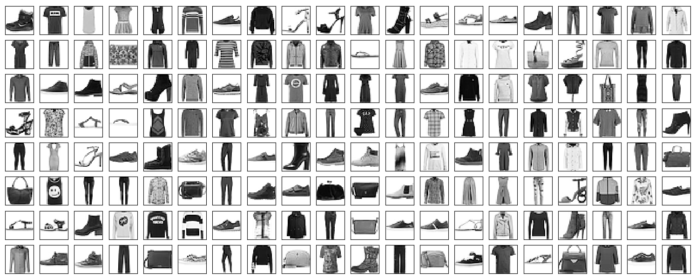


In [1]:
from tensorflow.keras import datasets, layers, models, utils
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

In [2]:
(x_train2d, y_train),(x_test2d, y_test) = datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
print(x_train2d.shape, y_train.shape)
print(x_test2d.shape, y_test.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


In [4]:
items = {0:'T-shirt/top', 1:'Trouser', 2:'Pullover', 3:'Dress',
         4:'Coat', 5:'Sandal', 6:'Shirt', 7:'Sneaker',
         8:'Bag', 9:'Ankel boot'}

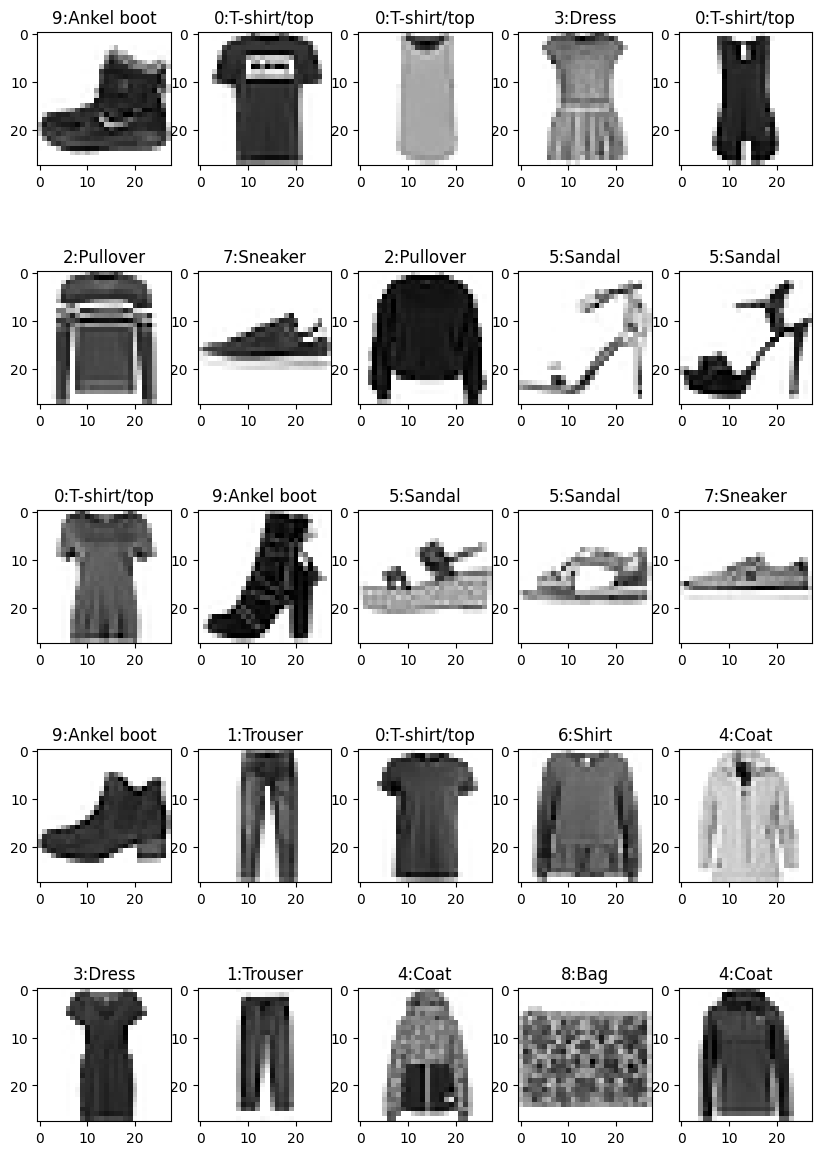

In [5]:
fig, axs = plt.subplots(5, 5, figsize=(10,15))
for i in range(5):
  for j in range(5):
    axs[i, j].set_title('{}:{}'.format(y_train[i*5+j], items[y_train[i*5+j]]))
    axs[i, j].imshow(x_train2d[i*5+j], cmap='gray_r')
plt.show()

In [6]:
x_train = x_train2d.reshape(-1, 28, 28, 1)
x_test = x_test2d.reshape(-1, 28, 28, 1)

In [7]:
x_train = x_train / 255
x_test = x_test / 255

#모델구성

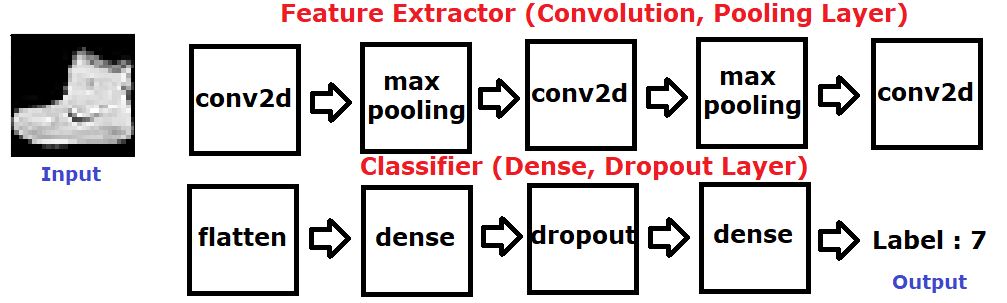

## Feature Extractor

In [8]:
# 32,62, 128
model = models.Sequential()
model.add(layers.Conv2D(32,(3,3),padding='same',activation='relu',input_shape=(28,28,1)))
model.add(layers.MaxPool2D((2,2),strides=2)) # 일반적으로  strides와 앞에 ()에 들어간 값이 같다.
model.add(layers.Conv2D(64,(3,3),padding='same',activation='relu'))
model.add(layers.MaxPool2D((2,2),strides=2))
model.add(layers.Conv2D(128,(3,3),padding='same',activation='relu'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 92,672 (362.00 KB)

 Trainable params: 92,672 (362.00 KB)

 Non-trainable params: 0 (0.00 B)

### Classifier

In [9]:
# 128 , 10
model.add(layers.Flatten()) # 직렬화
model.add(layers.Dense(128,activation='relu'))
model.add(layers.Dropout(0.3))
model.add(layers.Dense(10,activation='softmax'))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 896,906 (3.42 MB)

 Trainable params: 896,906 (3.42 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['acc'])

In [11]:
histroy = model.fit(x_train,y_train,epochs=10,validation_split=0.2) # 귀찮으니까 너가 인증 데이터 나눠줘

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - acc: 0.8306 - loss: 0.4698 - val_acc: 0.8884 - val_loss: 0.3010
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - acc: 0.8942 - loss: 0.2949 - val_acc: 0.9022 - val_loss: 0.2621
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - acc: 0.9114 - loss: 0.2441 - val_acc: 0.9119 - val_loss: 0.2449
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - acc: 0.9223 - loss: 0.2130 - val_acc: 0.9158 - val_loss: 0.2262
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - acc: 0.9315 - loss: 0.1848 - val_acc: 0.9187 - val_loss: 0.2234
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - acc: 0.9401 - loss: 0.1611 - val_acc: 0.9173 - val_loss: 0.2476
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - acc: 0.9460 - loss: 0.1421 - val_acc: 0.9212 - val_loss: 0.2326
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - acc: 0.9539 - loss: 0.1237 - val_acc: 0.9218 - val_loss: 0.2549
Epoch 9/10
1500/1500 ━━━━━━━━━━━━━━━━━━

In [19]:
def plot_history(history):
  plt.figure(figsize=(15,5))
  plt.subplot(1,2,1)
  plt.plot(history['acc'])
  plt.plot(history['val_acc'])
  plt.legend(['train','validation'])
  plt.title('ACC')

  plt.subplot(1,2,2)
  plt.plot(history['loss'])
  plt.plot(history['val_loss'])
  plt.legend(['train','validation'])
  plt.title('Loss')
  plt.show()

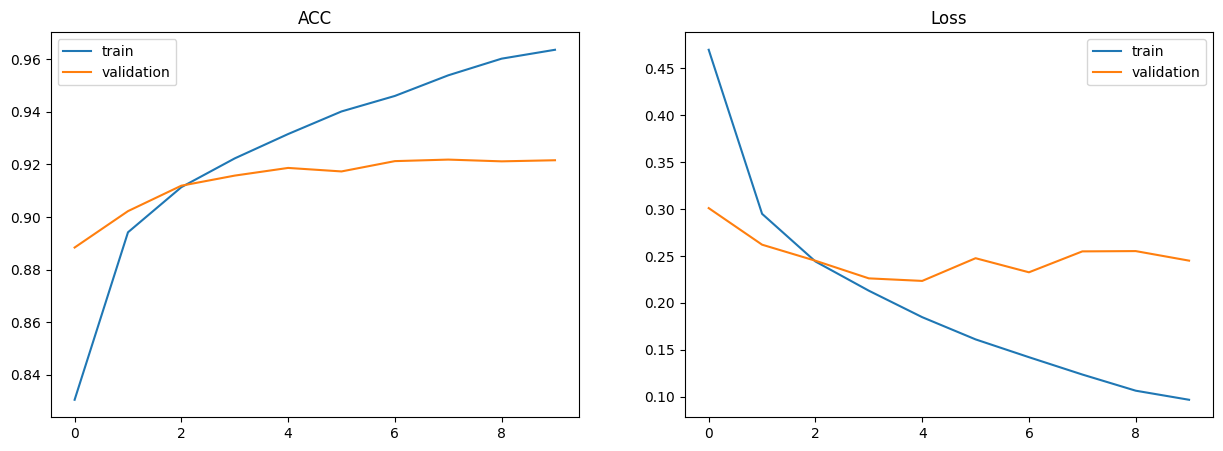

In [20]:
plot_history(histroy.history)

#Drop out
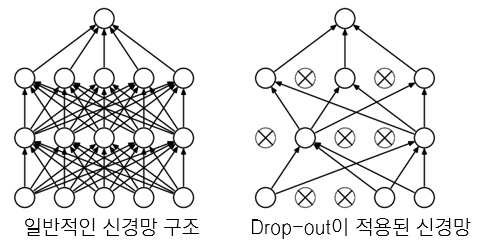

## BatchNormalization
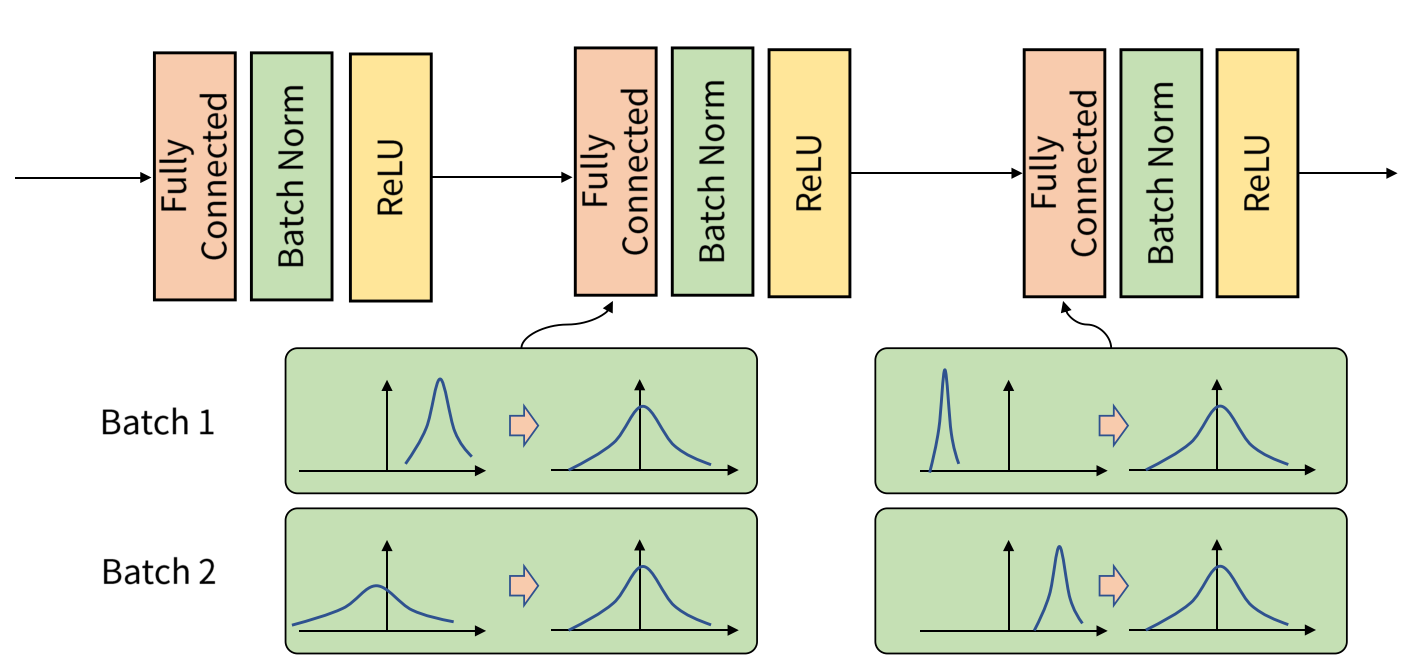

In [22]:
model2 = models.Sequential()
model2.add(layers.Conv2D(32,(3,3),padding='same',activation='relu',input_shape=(28,28,1)))
model2.add(layers.BatchNormalization()) # 데이터 정규화 / 과적합 방지
model2.add(layers.MaxPool2D((2,2),strides=2)) # 일반적으로  strides와 앞에 ()에 들어간 값이 같다.
model2.add(layers.Conv2D(64,(3,3),padding='same',activation='relu'))
model2.add(layers.BatchNormalization())
model2.add(layers.MaxPool2D((2,2),strides=2))
model2.add(layers.Conv2D(128,(3,3),padding='same',activation='relu'))

model2.add(layers.Flatten()) # 직렬화
model2.add(layers.Dense(128,activation='relu'))
model2.add(layers.Dropout(0.3))
model2.add(layers.Dense(10,activation='softmax'))
model2.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 897,290 (3.42 MB)

 Trainable params: 897,098 (3.42 MB)

 Non-trainable params: 192 (768.00 B)

In [23]:
model2.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['acc'])
history = model2.fit(x_train,y_train,epochs=10,validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - acc: 0.8556 - loss: 0.4041 - val_acc: 0.8920 - val_loss: 0.3010
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - acc: 0.8996 - loss: 0.2798 - val_acc: 0.9046 - val_loss: 0.2611
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - acc: 0.9127 - loss: 0.2376 - val_acc: 0.9019 - val_loss: 0.2848
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - acc: 0.9240 - loss: 0.2071 - val_acc: 0.9055 - val_loss: 0.2533
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - acc: 0.9333 - loss: 0.1832 - val_acc: 0.9147 - val_loss: 0.2694
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - acc: 0.9380 - loss: 0.1645 - val_acc: 0.9128 - val_loss: 0.2882
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - acc: 0.9443 - loss: 0.1533 - val_acc: 0.9143 - val_loss: 0.2618
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - acc: 0.9511 - loss: 0.1303 - val_acc: 0.9193 - val_loss: 0.2612
Epoch 9/10
1500/1500 ━━━━━━━━━━━━━━━━━

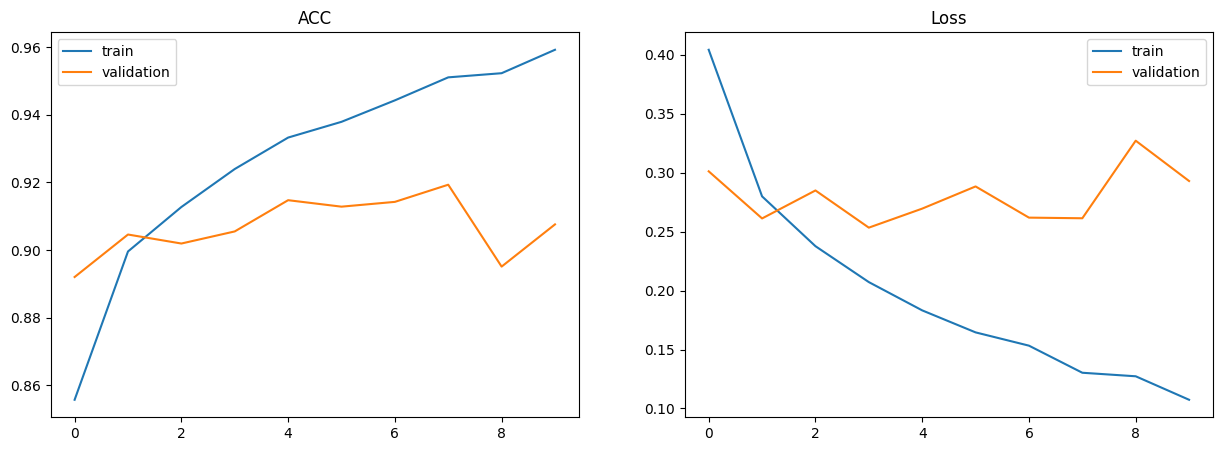

In [26]:
plot_history(history.history)

In [27]:
model2.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - acc: 0.9039 - loss: 0.3149


[0.31486883759498596, 0.9039000272750854]

## Callback

In [28]:
model3 = models.Sequential()
model3.add(layers.Conv2D(32,(3,3),padding='same',activation='relu',input_shape=(28,28,1)))
model3.add(layers.BatchNormalization()) # 데이터 정규화 / 과적합 방지
model3.add(layers.MaxPool2D((2,2),strides=2)) # 일반적으로  strides와 앞에 ()에 들어간 값이 같다.
model3.add(layers.Conv2D(64,(3,3),padding='same',activation='relu'))
model3.add(layers.BatchNormalization())
model3.add(layers.MaxPool2D((2,2),strides=2))
model3.add(layers.Conv2D(128,(3,3),padding='same',activation='relu'))

model3.add(layers.Flatten()) # 직렬화
model3.add(layers.Dense(128,activation='relu'))
model3.add(layers.Dropout(0.3))
model3.add(layers.Dense(10,activation='softmax'))
model3.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 897,290 (3.42 MB)

 Trainable params: 897,098 (3.42 MB)

 Non-trainable params: 192 (768.00 B)

In [29]:
model3.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['acc'])

In [30]:
checkpoint_cb = keras.callbacks.ModelCheckpoint('best_model.keras',save_best_only=True)
history = model3.fit(x_train,y_train,epochs=10,validation_split=0.2,callbacks=[checkpoint_cb])

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - acc: 0.8488 - loss: 0.4276 - val_acc: 0.8937 - val_loss: 0.2862
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - acc: 0.8965 - loss: 0.2889 - val_acc: 0.9003 - val_loss: 0.2682
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - acc: 0.9101 - loss: 0.2468 - val_acc: 0.8996 - val_loss: 0.2732
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - acc: 0.9195 - loss: 0.2164 - val_acc: 0.9143 - val_loss: 0.2433
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - acc: 0.9282 - loss: 0.1927 - val_acc: 0.9195 - val_loss: 0.2239
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - acc: 0.9375 - loss: 0.1667 - val_acc: 0.8901 - val_loss: 0.3366
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - acc: 0.9421 - loss: 0.1541 - val_acc: 0.9034 - val_loss: 0.3029
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - acc: 0.9483 - loss: 0.1364 - val_acc: 0.9208 - val_loss: 0.2383
Epoch 9/10
1500/1500 ━━━━━━━━━━━━━━━━━━

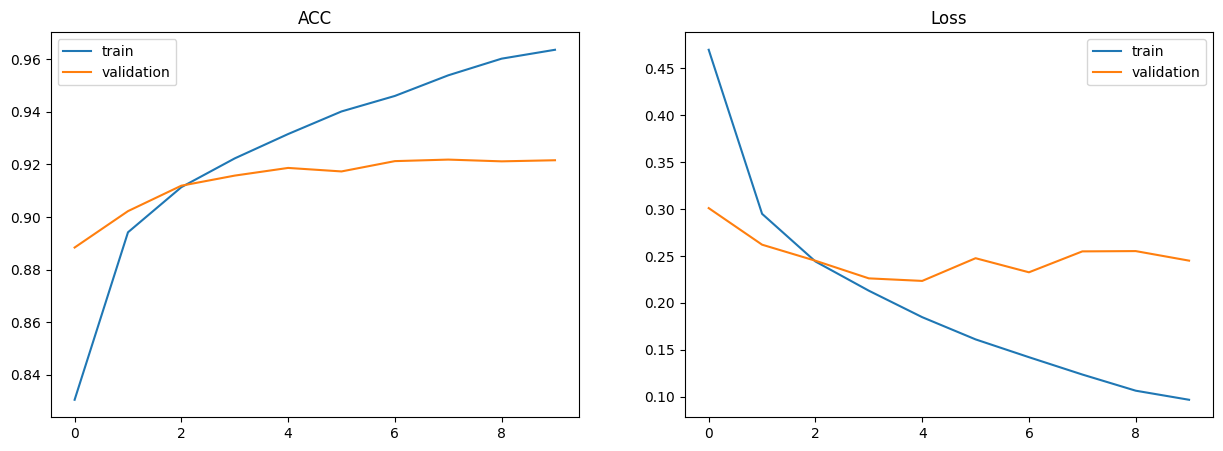

In [31]:
plot_history(histroy.history)

In [32]:
model3.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - acc: 0.9018 - loss: 0.3838


[0.38378196954727173, 0.9017999768257141]

In [33]:
model4 = models.Sequential()
model4.add(layers.Conv2D(32,(3,3),padding='same',activation='relu',input_shape=(28,28,1)))
model4.add(layers.BatchNormalization()) # 데이터 정규화 / 과적합 방지
model4.add(layers.MaxPool2D((2,2),strides=2)) # 일반적으로  strides와 앞에 ()에 들어간 값이 같다.
model4.add(layers.Conv2D(64,(3,3),padding='same',activation='relu'))
model4.add(layers.BatchNormalization())
model4.add(layers.MaxPool2D((2,2),strides=2))
model4.add(layers.Conv2D(128,(3,3),padding='same',activation='relu'))

model4.add(layers.Flatten()) # 직렬화
model4.add(layers.Dense(128,activation='relu'))
model4.add(layers.Dropout(0.3))
model4.add(layers.Dense(10,activation='softmax'))
model4.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 897,290 (3.42 MB)

 Trainable params: 897,098 (3.42 MB)

 Non-trainable params: 192 (768.00 B)

In [34]:
model4.compile(loss='sparse_categorical_crossentropy', optimizer='adam',metrics=['acc'])

In [38]:
checpoint_cb = keras.callbacks.ModelCheckpoint('best_model.keras',save_best_only=True)
# 정확도가 올라갔다가 내려가면 학습을 멈춰라 ((인내)몇번 참아줄까 가 patience=)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3,restore_best_weights=True)
history = model4.fit(x_train,y_train,epochs=10,validation_split=0.2,callbacks=[checkpoint_cb,early_stopping_cb])

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - acc: 0.9494 - loss: 0.1354 - val_acc: 0.9079 - val_loss: 0.3308
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - acc: 0.9546 - loss: 0.1214 - val_acc: 0.9033 - val_loss: 0.3215
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - acc: 0.9593 - loss: 0.1115 - val_acc: 0.9109 - val_loss: 0.3052
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - acc: 0.9627 - loss: 0.1001 - val_acc: 0.9208 - val_loss: 0.2746
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - acc: 0.9656 - loss: 0.0914 - val_acc: 0.9200 - val_loss: 0.2968
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - acc: 0.9654 - loss: 0.0932 - val_acc: 0.8810 - val_loss: 0.4924
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - acc: 0.9701 - loss: 0.0789 - val_acc: 0.9212 - val_loss: 0.3401


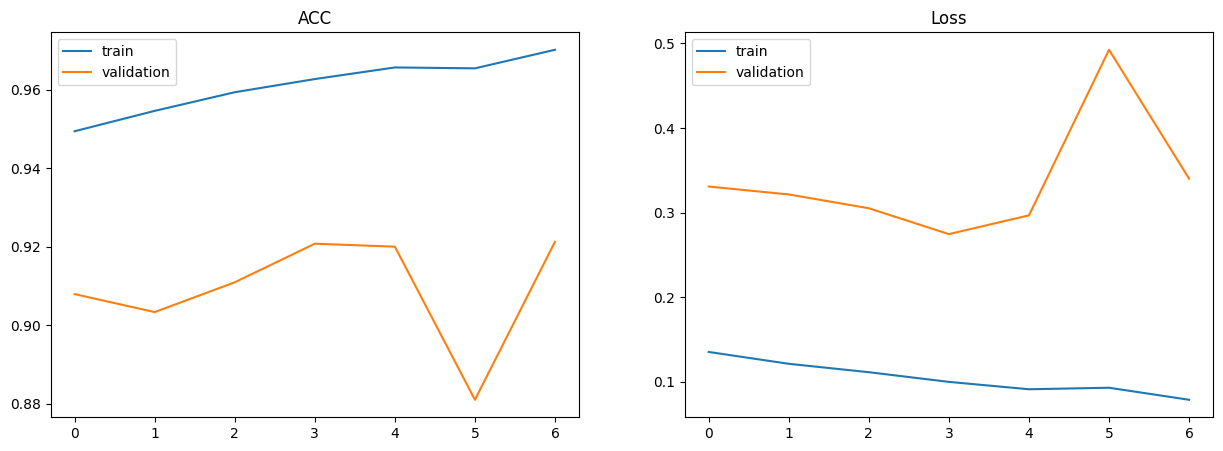

In [40]:
plot_history(history.history)

In [41]:
pred=model4.predict(x_test[0:25])
print(np.round(pred, decimals=3))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 744ms/step
[[0.    0.    0.    0.    0.    0.    0.    0.    0.    1.   ]
 [0.    0.    1.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    1.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    1.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.005 0.    0.    0.    0.008 0.    0.986 0.    0.    0.   ]
 [0.    1.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    1.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.001 0.    0.003 0.    0.996 0.    0.    0.   ]
 [0.    0.    0.    0.    0.    1.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    1.    0.    0.   ]
 [0.    0.    0.    0.    0.999 0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    1.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    1.    0.    0.   ]
 [0.    0.    0.    1.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.043 0.    0.956 0.    0.001 0.    0.    0.   ]
 [0.    1.    0.

In [42]:
np.argmax(pred,axis=1)

array([9, 2, 1, 1, 6, 1, 4, 6, 5, 7, 4, 5, 7, 3, 4, 1, 2, 4, 8, 0, 2, 5,
       7, 5, 1])

In [43]:
print(y_test[0:25])

[9 2 1 1 6 1 4 6 5 7 4 5 7 3 4 1 2 4 8 0 2 5 7 9 1]


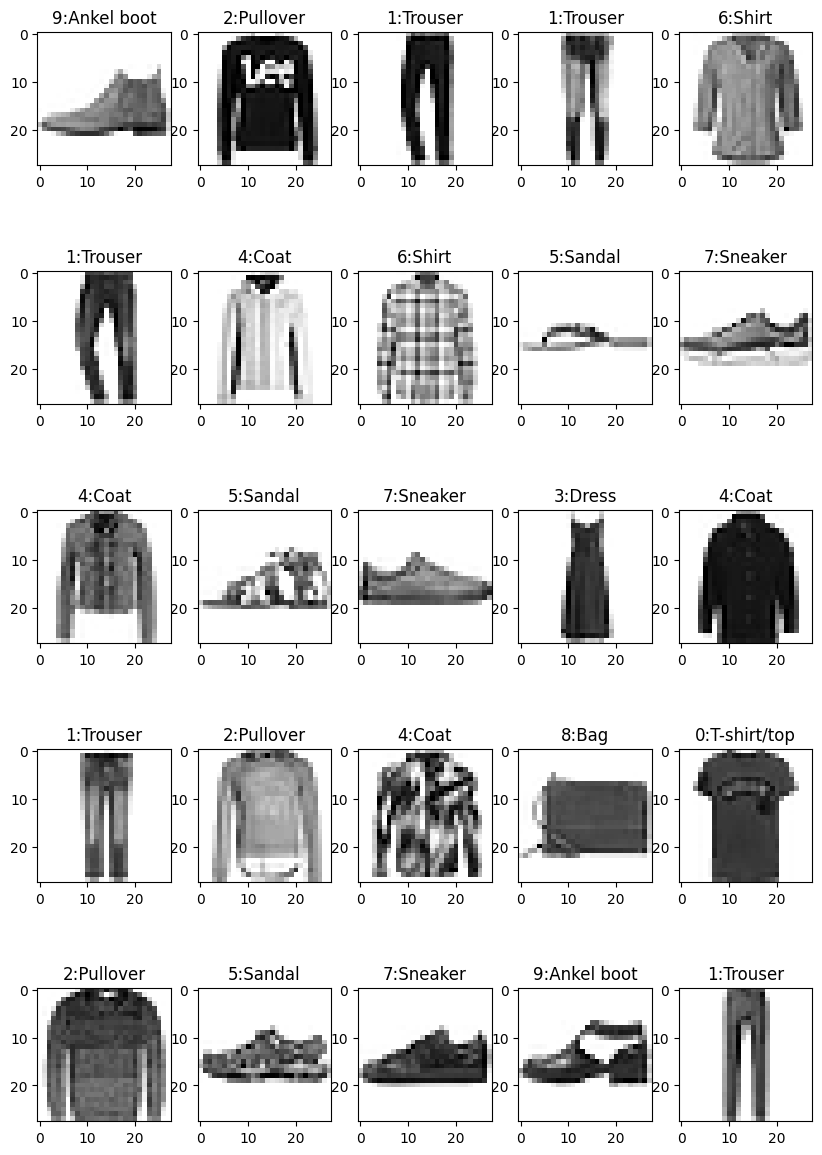

In [45]:
fig, axs = plt.subplots(5, 5, figsize=(10,15))
for i in range(5):
  for j in range(5):
    axs[i, j].set_title('{}:{}'.format(y_test[i*5+j], items[y_test[i*5+j]]))
    axs[i, j].imshow(x_test2d[i*5+j], cmap='gray_r')
plt.show()

## CNN의 시각화

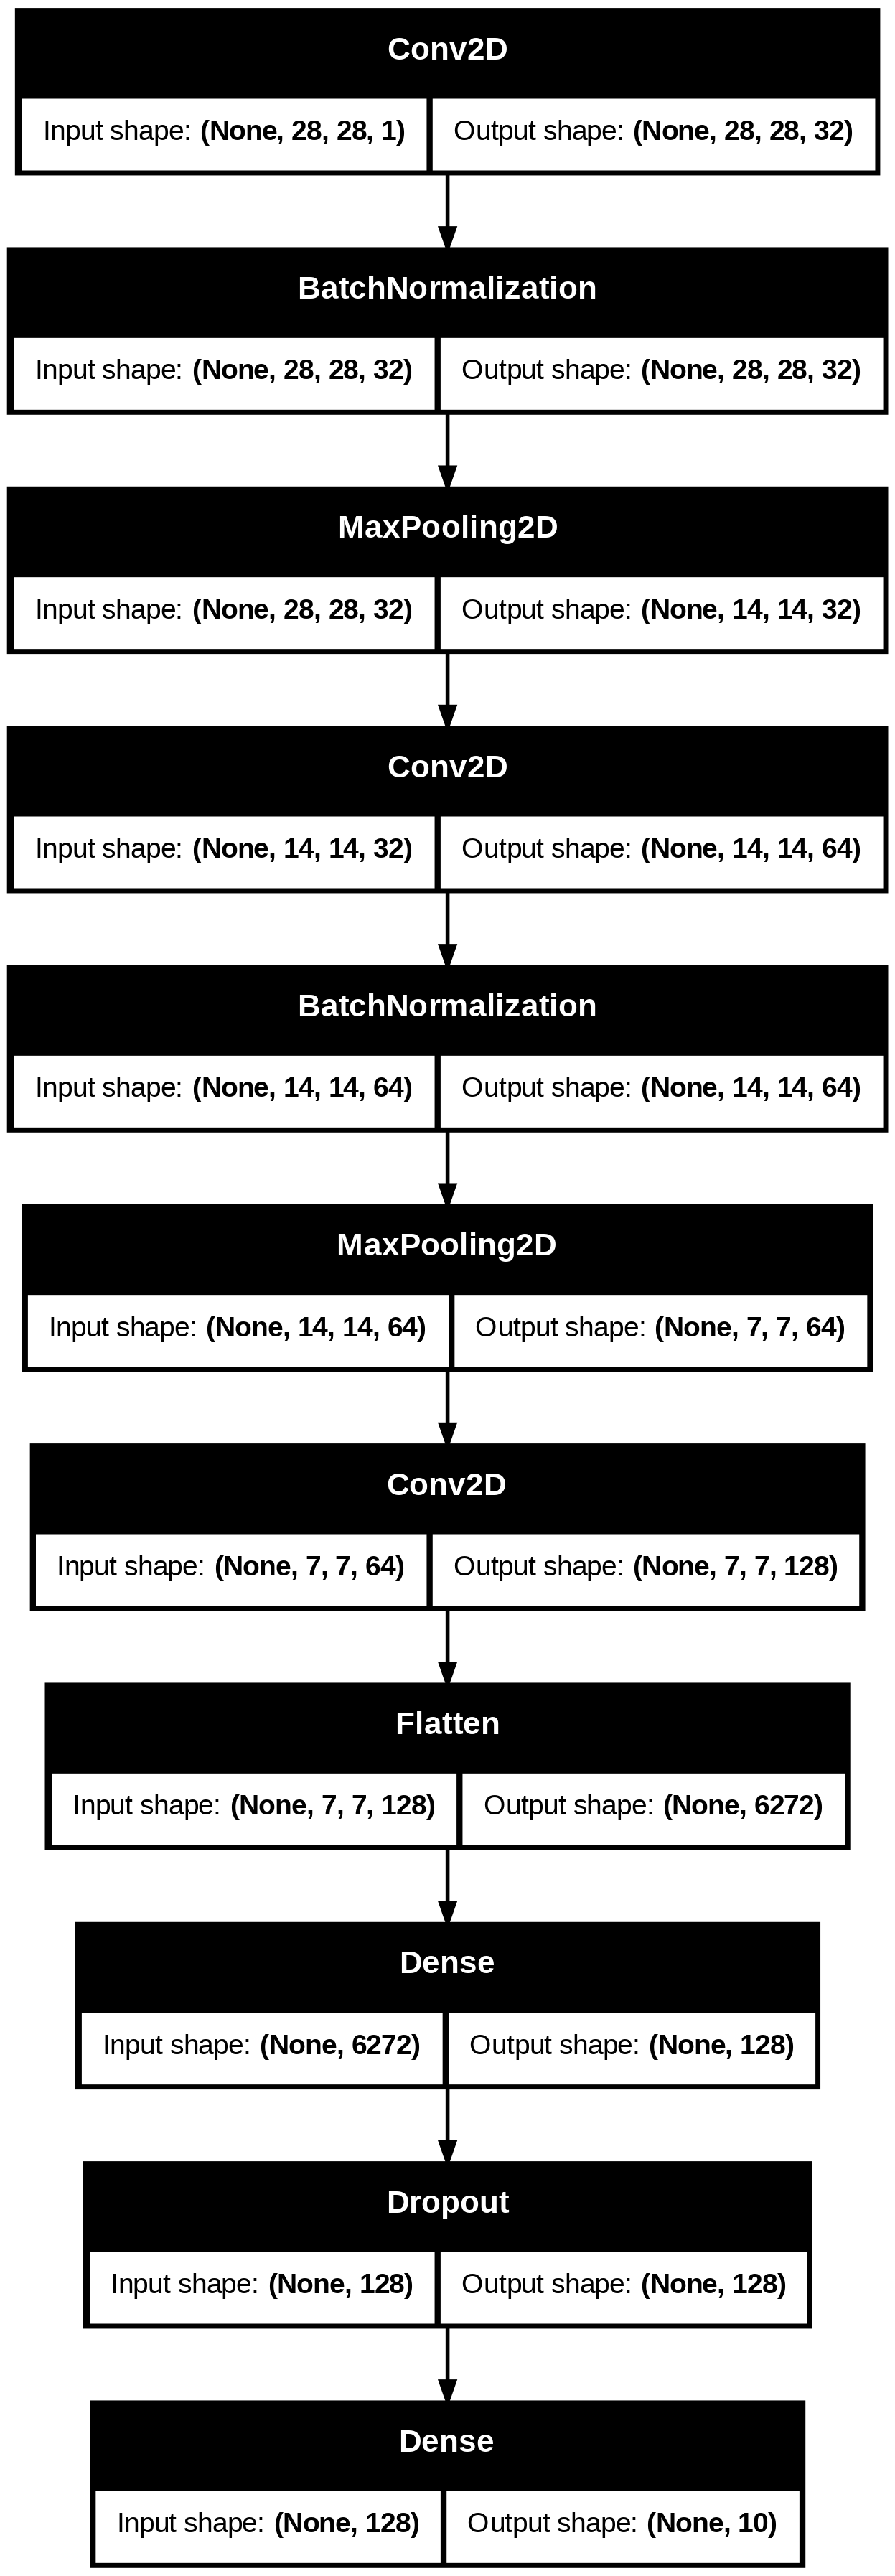

In [46]:
utils.plot_model(model4,show_shapes=True,to_file='fmist.png') # 각 층 마다 쉐입 보여준다. 파일로 저장

### 학습된 Conv층 가져오기

In [47]:
model4.layers

[<Conv2D name=conv2d_12, built=True>,
 <BatchNormalization name=batch_normalization_6, built=True>,
 <MaxPooling2D name=max_pooling2d_8, built=True>,
 <Conv2D name=conv2d_13, built=True>,
 <BatchNormalization name=batch_normalization_7, built=True>,
 <MaxPooling2D name=max_pooling2d_9, built=True>,
 <Conv2D name=conv2d_14, built=True>,
 <Flatten name=flatten_4, built=True>,
 <Dense name=dense_8, built=True>,
 <Dropout name=dropout_4, built=True>,
 <Dense name=dense_9, built=True>]

In [49]:
conv = model4.layers[0]
print(conv.weights[0].shape,conv.weights[1].shape)

(3, 3, 1, 32) (32,)


In [50]:
weights = conv.weights[0].numpy()
print(weights.shape)
print(weights)

(3, 3, 1, 32)
[[[[ 8.12993720e-02 -8.14720765e-02  2.30963141e-01 -1.01445131e-01
     2.14695465e-02  4.26096059e-02  8.26866925e-02 -3.48460376e-02
     2.18716040e-01  1.61384970e-01 -3.55173238e-02 -1.78636491e-01
     1.44623250e-01 -1.40591472e-01 -3.38369995e-01 -5.58626198e-04
    -2.63490885e-01  3.21950577e-02  1.58216506e-01  9.13923308e-02
     4.61059026e-02  1.31778256e-03  1.14602350e-01 -1.10981334e-02
    -1.83362454e-01 -1.69980526e-01  7.03357756e-02 -2.48544827e-01
    -7.26873502e-02 -1.27815250e-02  1.70365885e-01 -1.31789118e-01]]

  [[ 5.85439354e-02 -2.30558693e-01 -5.01538098e-01 -6.69784248e-02
    -7.55149722e-02 -1.41171813e-01  5.97971454e-02 -1.20939398e-02
    -1.39630109e-01 -2.87106663e-01  3.05320136e-02  3.17668058e-02
    -1.01249784e-01  4.60651256e-02 -1.29475802e-01  1.15069285e-01
    -1.10053062e-01 -8.97511840e-02 -2.11962372e-01 -1.92494050e-01
    -2.91910678e-01 -9.60631594e-02 -1.16144247e-01  1.92751795e-01
     1.64081424e-01 -3.83674502

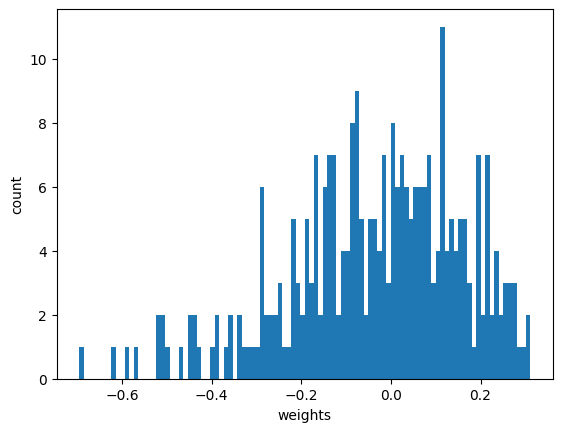

In [52]:
plt.hist(weights.flatten(),bins=100)
plt.xlabel('weights')
plt.ylabel('count')
plt.show()

In [53]:
weights[:,:,0,0] # 첫번째 필터(맨마지막 매개변수)의 첫번째 채널(세번째 매개변수)
# 절대값이 큰 애들이 피처를 만들어내는 것 (강화시키는 것)

array([[ 0.08129937,  0.05854394,  0.17057543],
       [ 0.21972656, -0.08956897, -0.38975203],
       [-0.01605792, -0.36779487, -0.35984984]], dtype=float32)

In [54]:
weights[:,:,0,1] # 두번째 필터

array([[-0.08147208, -0.2305587 , -0.11625529],
       [ 0.19964711,  0.21399674, -0.0633212 ],
       [-0.09798966,  0.02096014,  0.08585468]], dtype=float32)

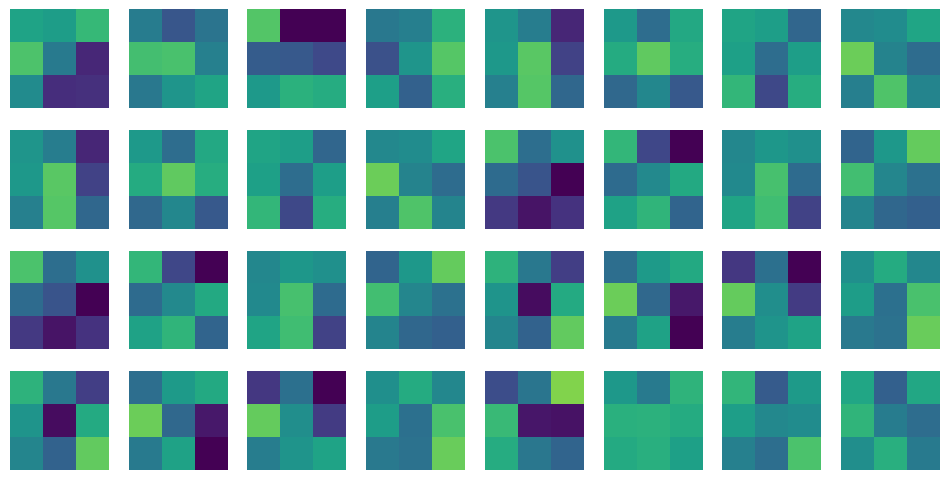

In [55]:
fig, axs = plt.subplots(4, 8, figsize=(12,6))
for i in range(4):
  for j in range(8):
    axs[i, j].imshow(weights[:,:,0,i*4+j], vmin=-0.5,vmax=0.5)
    axs[i,j].axis('off') # 축 안나오게
plt.show()

In [56]:
init_model = keras.Sequential()
init_model.add(layers.Conv2D(32,(3,3),padding='same',activation='relu',input_shape=(28,28,1)))
init_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 320 (1.25 KB)

 Trainable params: 320 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

In [57]:
new_conv = init_model.layers[0]
print(new_conv.weights[0].shape,new_conv.weights[1].shape)

(3, 3, 1, 32) (32,)


In [58]:
new_weights = new_conv.weights[0].numpy()
print(new_weights.shape)
print(new_weights)

(3, 3, 1, 32)
[[[[-0.09209312 -0.01570363 -0.0951112   0.01158483 -0.12264104
    -0.11690181  0.01236844  0.06265156  0.13004507 -0.11126885
     0.10173854 -0.05509384  0.03049494  0.06332159 -0.05473572
    -0.02608075  0.12980996  0.12120984 -0.06901469  0.12176882
     0.12429868 -0.0910067  -0.1234867   0.0791388  -0.13683482
     0.02794832 -0.10924524 -0.05597498 -0.07346054  0.10255031
    -0.08741681 -0.08019406]]

  [[-0.05375545 -0.0522371  -0.10944961  0.05689675 -0.07265934
    -0.12285127 -0.02718778  0.00993566  0.0353692  -0.00672156
    -0.10139683  0.03231968 -0.1037323   0.12797172  0.1303202
    -0.01078546  0.0433777   0.06951649 -0.12514497 -0.04158027
     0.02385113  0.11748557  0.0074991  -0.0063452   0.10962577
     0.02953513  0.1317795  -0.12976731  0.04339288 -0.05438691
    -0.06528871  0.04217856]]

  [[-0.05796735 -0.12751275 -0.02823236  0.13988255  0.09051421
     0.12582211 -0.01246496  0.12690939  0.11738984  0.03408416
     0.13840605 -0.08798242 -

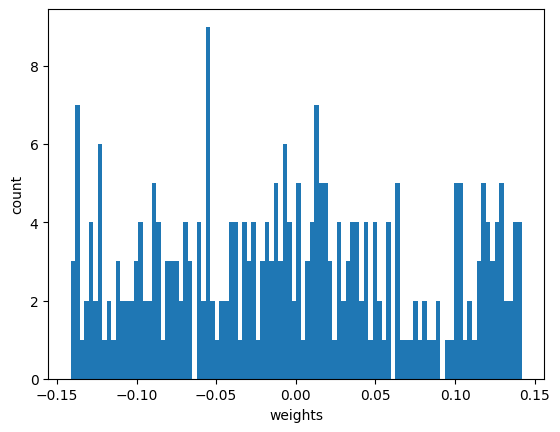

In [59]:
plt.hist(new_weights.flatten(),bins=100)
plt.xlabel('weights')
plt.ylabel('count')
plt.show()

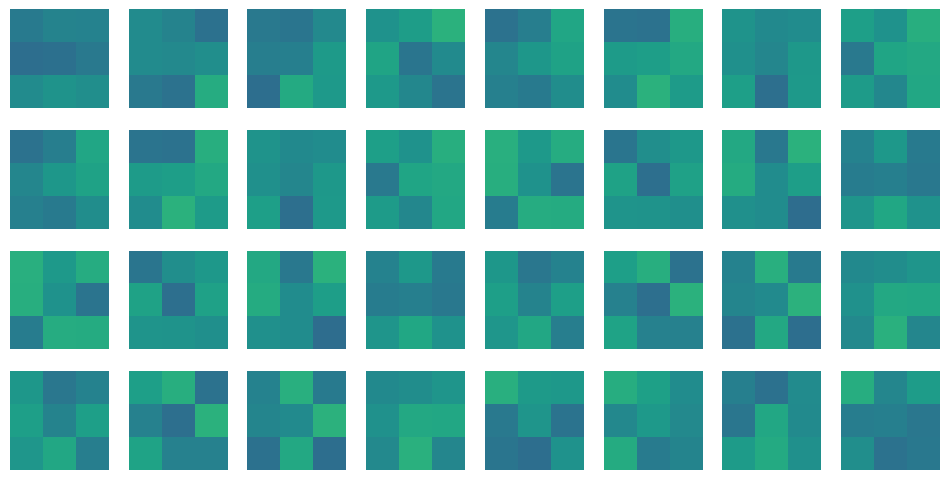

In [60]:
fig, axs = plt.subplots(4, 8, figsize=(12,6))
for i in range(4):
  for j in range(8):
    axs[i, j].imshow(new_weights[:,:,0,i*4+j], vmin=-0.5,vmax=0.5)
    axs[i,j].axis('off') # 축 안나오게
plt.show()

### 필터를 거친 이미지 확인하기

In [62]:
conv1 = keras.Model(model4.inputs[0],model4.layers[0].output) # 모델4의 첫번째 층만 가지고 모델을 만듬
conv1.summary()

Model: "functional_54"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 320 (1.25 KB)

 Trainable params: 320 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

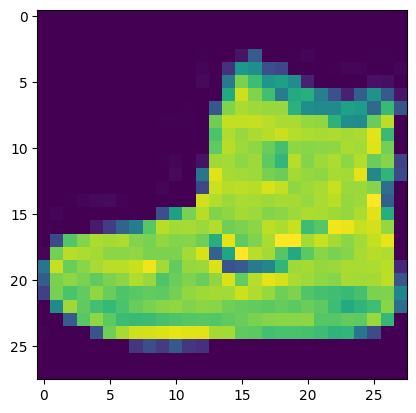

In [63]:
plt.imshow(x_train2d[0])

In [64]:
feature_map1 = conv1.predict(x_train[0:1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step


In [65]:
print(feature_map1.shape)

(1, 28, 28, 32)


In [68]:
feature_map1[0,:,:,2]

array([[2.64881784e-03, 2.64881784e-03, 2.64881784e-03, 2.64881784e-03,
        2.64881784e-03, 2.64881784e-03, 2.64881784e-03, 2.64881784e-03,
        2.64881784e-03, 2.64881784e-03, 2.64881784e-03, 2.64881784e-03,
        2.64881784e-03, 2.64881784e-03, 2.64881784e-03, 2.64881784e-03,
        2.64881784e-03, 2.64881784e-03, 2.64881784e-03, 2.64881784e-03,
        2.64881784e-03, 2.64881784e-03, 2.64881784e-03, 2.64881784e-03,
        2.64881784e-03, 2.64881784e-03, 2.64881784e-03, 2.64881784e-03],
       [2.64881784e-03, 2.64881784e-03, 2.64881784e-03, 2.64881784e-03,
        2.64881784e-03, 2.64881784e-03, 2.64881784e-03, 2.64881784e-03,
        2.64881784e-03, 2.64881784e-03, 2.64881784e-03, 2.64881784e-03,
        2.64881784e-03, 2.64881784e-03, 2.64881784e-03, 2.64881784e-03,
        2.64881784e-03, 2.64881784e-03, 2.64881784e-03, 2.64881784e-03,
        2.64881784e-03, 2.64881784e-03, 2.64881784e-03, 2.64881784e-03,
        2.64881784e-03, 2.64881784e-03, 2.64881784e-03, 2.64881

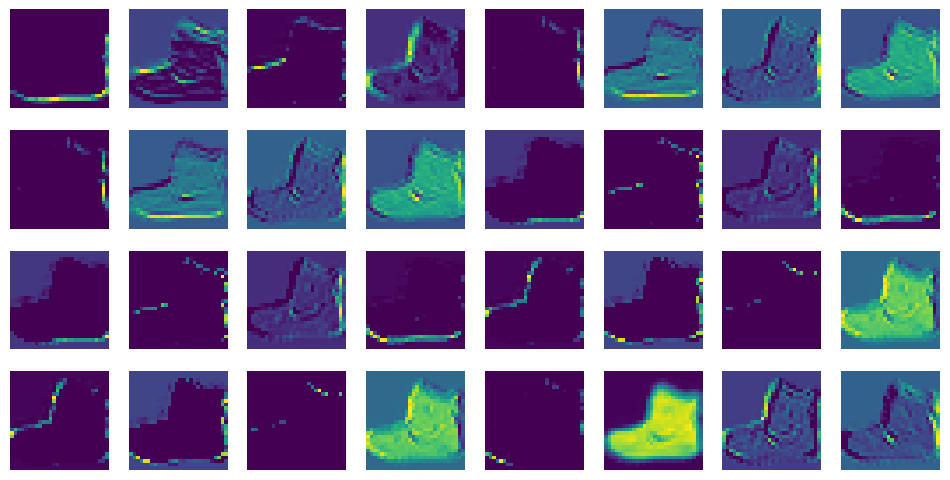

In [71]:
fig, axs = plt.subplots(4, 8, figsize=(12,6))
for i in range(4):
  for j in range(8):
    axs[i, j].imshow(feature_map1[0,:,:,i*4+j])
    axs[i,j].axis('off') # 축 안나오게
plt.show()

In [72]:
model4.layers

[<Conv2D name=conv2d_12, built=True>,
 <BatchNormalization name=batch_normalization_6, built=True>,
 <MaxPooling2D name=max_pooling2d_8, built=True>,
 <Conv2D name=conv2d_13, built=True>,
 <BatchNormalization name=batch_normalization_7, built=True>,
 <MaxPooling2D name=max_pooling2d_9, built=True>,
 <Conv2D name=conv2d_14, built=True>,
 <Flatten name=flatten_4, built=True>,
 <Dense name=dense_8, built=True>,
 <Dropout name=dropout_4, built=True>,
 <Dense name=dense_9, built=True>]

In [75]:
# 두번째 conv
conv2 = keras.Model(model4.inputs[0],model4.layers[3].output)
conv2.summary()

Model: "functional_57"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,944 (74.00 KB)

 Trainable params: 18,880 (73.75 KB)

 Non-trainable params: 64 (256.00 B)

In [76]:
feature_map2 = conv2.predict(x_train[0:1])
print(feature_map2.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 956ms/step
(1, 14, 14, 64)


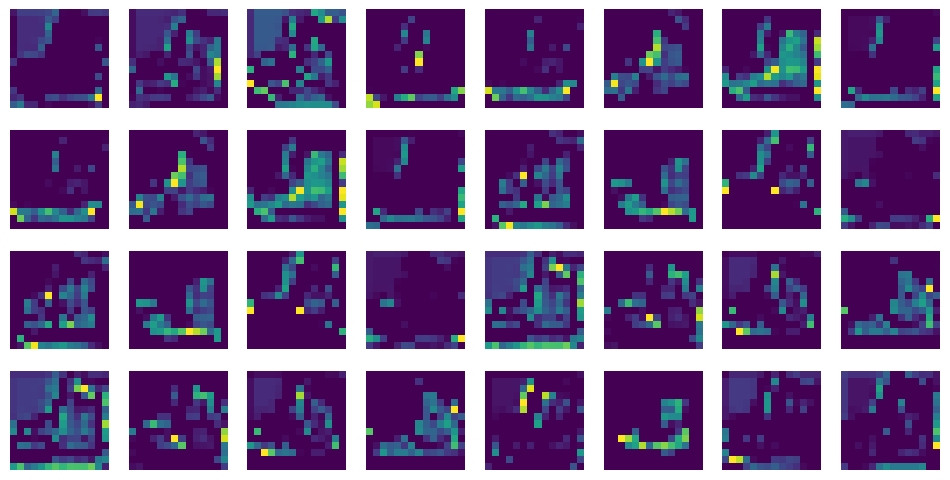

In [77]:
fig, axs = plt.subplots(4, 8, figsize=(12,6))
for i in range(4):
  for j in range(8):
    axs[i, j].imshow(feature_map2[0,:,:,i*4+j])
    axs[i,j].axis('off') # 축 안나오게
plt.show()

In [78]:
model4.layers

[<Conv2D name=conv2d_12, built=True>,
 <BatchNormalization name=batch_normalization_6, built=True>,
 <MaxPooling2D name=max_pooling2d_8, built=True>,
 <Conv2D name=conv2d_13, built=True>,
 <BatchNormalization name=batch_normalization_7, built=True>,
 <MaxPooling2D name=max_pooling2d_9, built=True>,
 <Conv2D name=conv2d_14, built=True>,
 <Flatten name=flatten_4, built=True>,
 <Dense name=dense_8, built=True>,
 <Dropout name=dropout_4, built=True>,
 <Dense name=dense_9, built=True>]

In [79]:
# 세번째 conv3
conv3 = keras.Model(model4.inputs[0],model4.layers[6].output)
conv3.summary()

Model: "functional_58"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,056 (363.50 KB)

 Trainable params: 92,864 (362.75 KB)

 Non-trainable params: 192 (768.00 B)

In [80]:
feature_map3 = conv3.predict(x_train[0:1])
print(feature_map3.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step
(1, 7, 7, 128)


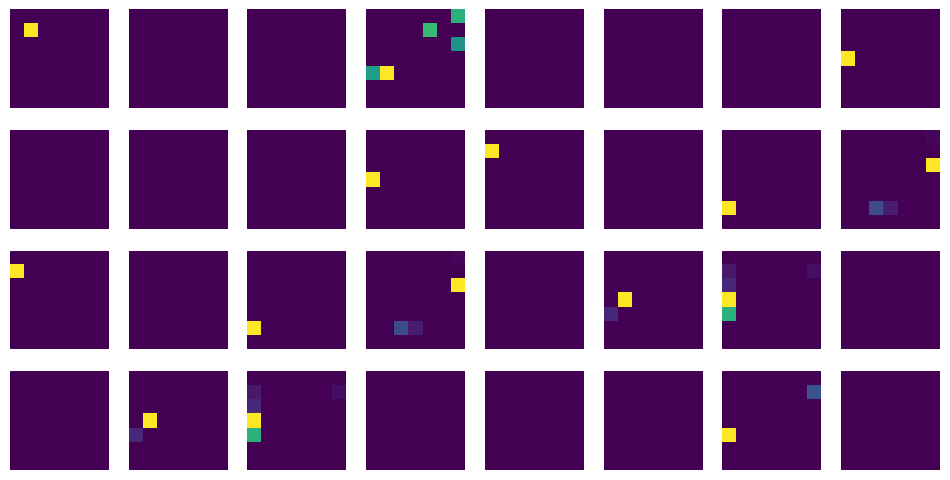

In [81]:
fig, axs = plt.subplots(4, 8, figsize=(12,6))
for i in range(4):
  for j in range(8):
    axs[i, j].imshow(feature_map3[0,:,:,i*4+j])
    axs[i,j].axis('off') # 축 안나오게
plt.show()